# Домашнее задание: 3D-реконструкция объекта по съёмке с телефона

Вы выбираете объект, снимаете его на телефон (**видео или серию фотографий**), калибруете камеру телефона и собираете
пайплайн **Structure-from-Motion**: от кадров до поз камер и облака 3D-точек.

```
съёмка ─► калибровка K ─► ключевые кадры ─► особые точки и сопоставления ─► SfM ─► облако точек ─► плотное облако (ректификация пар + SGBM)
```


Можно пользоваться функциями OpenCV (`calibrateCamera`, `findEssentialMat`, `recoverPose`, `solvePnPRansac`, `triangulatePoints`, …)
и кодом с семинара. Нельзя вызывать готовый SfM (COLMAP, pycolmap, OpenMVG, …) внутри своего пайплайна.

#### Выполнить Части 1 - 5. Сдать этот ноутбук, выполненный целиком.

# Часть 0. Съёмка

## 0.1 Что снимать

Хороший объект:
* **неподвижный** — не двигается и не меняет форму, пока вы снимаете;
* **текстурный** — много мелких деталей, надписей, неровностей: именно по ним находятся и сопоставляются особые точки;
* **матовый** — без бликов, отражений и прозрачных частей;
* **его можно обойти** хотя бы на 90–180° (идеально — на все 360°);
* размером от кроссовка до здания. Совсем маленькие предметы (< 10 см) сложнее: нужна съёмка вблизи, а там мала глубина резкости.

Примеры, от простого к сложному:

| Объект | Сложность | Комментарий |
|---|---|---|
| Памятник, скульптура в парке, угол здания, крыльцо | ★ | много текстуры и рельефа; обходите по дуге |
| Пень, корни, большие камни, ствол дерева | ★ | идеальная природная текстура |
| Стопка книг, рюкзак, фигурка, горшок с растением | ★★ | поставьте на газету или ковёр с узором — текстурный фон тоже помогает |
| Стол с предметами, уголок комнаты | ★★ | двигайтесь вдоль сцены, а не поворачивайтесь на месте |
| **Лицо**  | ★★★ | Поворачивать голову перед неподвижной камерой нельзя: фон при этом стоит на месте, и сцена перестаёт быть жёсткой — SfM сломается. Модель смотрит в одну точку, держит нейтральное выражение лица, не разговаривает, по возможности не моргает на ключевых кадрах. Оператор обходит голову по дуге ≈180° (от уха до уха) на расстоянии 50–80 см, 2–3 прохода на разной высоте (на уровне глаз, чуть выше, чуть ниже). Лицо занимает бо́льшую часть кадра. |

Плохие объекты: машины, стекло, зеркала, металлические и глянцевые вещи, однотонные предметы и белые стены,
повторяющиеся узоры (плитка, жалюзи, решётки), всё, что шевелится (листья на ветру, люди).


## 0.2 Видео или фото?

Подходит и то и другое: пайплайн принимает видеофайл или папку с фотографиями.

| | Видео | Серия фото |
|---|---|---|
| Резкость кадров | ниже (смаз при движении) | выше |
| Настройка телефона | нужно стороннее приложение, чтобы выключить стабилизацию | хватает штатной камеры |
| Разрешение | 1920×1080 | 12 Мп и больше (в ноутбуке кадры уменьшаются) |
| Выбор кадров | автоматически, в части 2 | вы сами, во время съёмки |
| Скорость съёмки | быстро | нужно сделать 40–100 снимков |

**Видео:** 30–90 секунд. Двигайтесь **медленно и плавно** (полный круг вокруг объекта — примерно минута), без резких поворотов;
объект всё время в кадре и занимает бо́льшую его часть.

**Фото:** 40–100 снимков, шаг 5–10° вокруг объекта (соседние кадры перекрываются на 70% и больше). Снимайте **по порядку обхода**:
порядок имён файлов важен. 

**Как двигаться (для обоих вариантов):**
* ✅ обходите объект по дуге или по кругу, камера смотрит на объект; 1–3 прохода на разной высоте;
* ❌ **не стойте на месте, поворачивая телефон.** При чистом повороте камеры нет параллакса, и глубину восстановить нельзя —
  это вырожденный случай;
* ❌ не пользуйтесь зумом — подходите ближе сами;
* ❌ не снимайте против яркого света.

## 0.3 Приложения и настройки

Главное правило: **матрица $K$ должна быть одной и той же во всех кадрах — и в калибровке, и в съёмке объекта.**
Поэтому фиксируем всё, что геометрически меняет изображение:

| Что зафиксировать | Почему |
|---|---|
| Основной объектив **1×**, без зума | у каждого объектива своя $K$; зум меняет фокусное расстояние |
| **Выключить автопереключение на макро / ультраширокий** | iPhone сам переключает объектив, когда подносишь его близко к объекту |
| **Выключить стабилизацию видео** | электронная стабилизация по-разному обрезает и деформирует каждый кадр — у каждого кадра получается своя $K$ |
| **Заблокировать фокус** (AF lock или ручной фокус) | при перефокусировке немного меняется фокусное расстояние |
| Заблокировать экспозицию (желательно) | постоянная яркость — лучше сопоставления |
| Одно разрешение и одна ориентация (лучше горизонтальная) | $K$ зависит от размера кадра; при повороте телефона меняются местами $f_x, f_y$ и $c_x, c_y$ |
| Выключить HDR, ночной режим, «Портрет», фильтры, Live Photo, beauty-эффекты | вычислительная фотография «дорисовывает» кадр |

**iPhone**
* *Видео:* **Blackmagic Camera** (бесплатно, App Store). В настройках: разрешение 1920×1080, кодек H.264 или H.265
  (не ProRes и не Blackmagic RAW — это огромные файлы), 30 кадров/с; **стабилизация — Off**; объектив 1×.
  Нажмите на объект и заблокируйте фокус (или выставьте его вручную) и экспозицию; выдержка 1/100 с или короче — меньше смаза.
* *Фото:* штатная «Камера». Настройки → Камера → Форматы → **«Наиболее совместимый»** (JPEG вместо HEIC: OpenCV не читает HEIC).
  Настройки → Камера → **«Управление макросъёмкой»** — включить, затем в приложении выключить значок цветка (макро).
  Режим «Фото», объектив 1×, Live Photo, ночной режим и вспышка — выкл.
  **Долгое нажатие на объект → «Блокировка AE/AF»** — блокировка сохраняется между снимками.

**Android**
* *Видео:* **Blackmagic Camera** (бесплатно, Google Play; работает не на всех телефонах — в основном на свежих Samsung Galaxy,
  Google Pixel и некоторых других) — настройки те же, что для iPhone. Если телефон не поддерживается — **Open Camera**
  (бесплатно, открытый код): Настройки → Настройки видео → **стабилизация видео — выкл.**, разрешение 1080p;
  режим фокуса — «Заблокирован» (Locked) или ручной; включите блокировку экспозиции. Для ручных режимов в настройках включите Camera2 API.
* *Фото:* Open Camera — режим «Стандарт» (без HDR / NR / DRO), JPEG, фокус «Заблокирован» или ручной, блокировка экспозиции.
  Подойдёт и штатная камера в режиме «Про» с ручным фокусом, если в нём не переключаются объективы.

Названия пунктов меню немного отличаются в разных версиях приложений и телефонов. Перед съёмкой убедитесь,
что стабилизация выключена, фокус заблокирован и объектив — 1×.

**Перенос на компьютер — только оригиналы.**

## 0.4 Калибровочная доска

Калибруем по доске **ChArUco** — это шахматная доска с ArUco-маркерами в белых клетках. У каждого маркера свой номер,
поэтому каждый угол доски опознаётся сам по себе: углы находятся, даже когда доска видна лишь частично или сильно наклонена.
Картинку доски сохраняет ячейка 1.1: `assets/charuco_board.png`.

Доску не нужно вращать в руках: откройте её на экране ноутбука и обходите ноутбук с телефоном.
Для калибровки важно только взаимное положение камеры и доски, поэтому «наклонить доску на 30°» и «зайти сбоку на 30°» — одно и то же.

### Подготовка экрана

1. Откройте `charuco_board.png` **на весь экран** в просмотрщике картинок. Картинку не растягивайте: клетки на экране должны остаться квадратными.
2. Яркость — на максимум.
3. Уберите блики: в экране не должен отражаться свет.

### Как двигаться с камерой (видео 30–60 с или 25–40 фото)

Снимайте **с теми же настройками, что и объект** (таблица 0.3): объектив 1×, горизонтальная ориентация, фокус и экспозиция заблокированы.
Удобнее всего работать с расстояния 30–80 см: если доска на кадрах размыта — фокус не тот.

1. **Прямо перед экраном.** Встаньте напротив ноутбука, доска занимает примерно половину кадра. Это стартовая точка.
2. **Углы и края кадра.** Не сходя с места, поворачивайте телефон так, чтобы доска побывала по очереди **в каждом из четырёх углов кадра**
   и **у каждого края**. Там дисторсия сильнее всего, а без точек в углах её не оценить. Доска может частично выходить за край кадра — ChArUco это допускает.
3. **Наклоны.** Обойдите ноутбук по дуге **влево и вправо**, чтобы смотреть на экран под углом 30–45°; затем поднимите телефон
   и снимайте **сверху**, опустите — **снизу**, всё время глядя на доску. На каждом наклоне снова проведите доску по углам кадра.
   Больше 50–60° не наклоняйтесь: у экрана под большим углом падает контраст, и маркеры перестают находиться.
4. **Расстояния.** Подойдите ближе (доска заполняет кадр и выходит за края) и отойдите дальше (доска занимает около четверти кадра).
5. **Поворот вокруг оси объектива.** Несколько кадров с телефоном, повёрнутым на 15–30° вокруг оси объектива (как руль).
   В вертикальную ориентацию телефон **не переводите**: у вертикального кадра другой размер и другая $K$.


## 0.5 Порядок съёмки

1. Настройте приложение (таблица 0.3), заблокируйте фокус и экспозицию, наведя камеру на объект.
2. **Снимите калибровку** (доску), **ничего не меняя** в настройках.
3. **Снимите объект.**

Калибровку и объект снимайте **одним способом** (оба видео или обе серии фото): у видео и фото разное разрешение и разная обрезка сенсора.

In [5]:
from itertools import combinations
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from scipy.optimize import least_squares
from scipy.sparse import coo_matrix

# import plotly.io as pio; pio.renderers.default = "browser"   # раскомментируйте, если 3D-графики не отображаются в IDE
%config InlineBackend.figure_formats = ["jpeg"]
plt.rcParams["figure.dpi"] = 100
np.set_printoptions(precision=4, suppress=True)

assert tuple(map(int, cv2.__version__.split(".")[:2])) >= (4, 8), "нужен OpenCV >= 4.8 (новый API ChArUco)"
print("OpenCV", cv2.__version__)

OpenCV 5.0.0


In [ ]:
CALIB_INPUT = "assets/calibration.mov"      # видео или папка с фото доски
SCENE_INPUT = "assets/sfm.mov"      # видео или папка с фото объекта

WORK_MAX_SIDE = 1600      # кадры уменьшаются так, чтобы большая сторона была не больше этого числа
VIDEO_FPS = 2.0           # сколько кадров в секунду брать из видео объекта (ключевые кадры выберем из них)
MAX_FRAMES = 100          # защита от переполнения памяти

OUT_DIR = Path(f"outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

### Загрузка кадров (дано)

Кадры из видео и фотографии приводятся к одному **рабочему разрешению** (`WORK_MAX_SIDE`). Калибровка и съёмка объекта должны
иметь одинаковое исходное разрешение, тогда и рабочее разрешение совпадёт, и найденная $K$ подойдёт для кадров объекта.

In [3]:
IMG_EXT = {".jpg", ".jpeg", ".png", ".ppm", ".bmp", ".tif", ".tiff"}
VIDEO_EXT = {".mp4", ".mov", ".m4v", ".avi", ".mkv"}


def to_work_size(img):
    s = WORK_MAX_SIDE / max(img.shape[:2])
    return cv2.resize(img, None, fx=s, fy=s, interpolation=cv2.INTER_AREA) if s < 1 else img


def load_frames(path, fps=VIDEO_FPS, max_frames=MAX_FRAMES):
    """Кадры из видео (fps штук в секунду) или все изображения из папки (в алфавитном порядке).
    Возвращает (names, images): images — RGB-кадры в рабочем разрешении."""
    path = Path(path)
    names, images = [], []
    if path.is_dir():
        heic = [p.name for p in path.iterdir() if p.suffix.lower() in {".heic", ".heif"}]
        if heic:
            print(f"пропущено {len(heic)} HEIC-файлов: OpenCV их не читает, снимайте в JPEG («Наиболее совместимый»)")
        for p in sorted(p for p in path.iterdir() if p.suffix.lower() in IMG_EXT)[:max_frames]:
            img = cv2.imread(str(p))                        # поворот по EXIF применяется автоматически
            names.append(p.name)
            images.append(to_work_size(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)))
    elif path.suffix.lower() in VIDEO_EXT and path.exists():
        cap = cv2.VideoCapture(str(path))
        assert cap.isOpened(), f"не удалось открыть {path}"
        video_fps = cap.get(cv2.CAP_PROP_FPS) or 30
        step = max(1, round(video_fps / fps))
        k = 0
        while len(images) < max_frames and cap.grab():
            if k % step == 0:
                _, frame = cap.retrieve()
                names.append(f"{path.stem}_{k:05d}")
                images.append(to_work_size(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
            k += 1
        cap.release()
        print(f"{path.name}: {video_fps:.0f} кадров/с, {k} кадров ({k / video_fps:.0f} с), взят каждый {step}-й")
    else:
        raise FileNotFoundError(f"{path}: нужна папка с фото или видеофайл ({', '.join(sorted(VIDEO_EXT))})")
    assert images, f"{path}: не найдено ни одного кадра"
    sizes = {im.shape[:2] for im in images}
    assert len(sizes) == 1, f"кадры разного размера {sizes}: снимайте в одной ориентации и одном разрешении"
    return names, images


def show_grid(images, titles=None, ncols=6, width=16):
    nrows = int(np.ceil(len(images) / ncols))
    h, w = images[0].shape[:2]
    fig, axes = plt.subplots(nrows, ncols, figsize=(width, width / ncols * h / w * nrows + 0.3 * nrows), squeeze=False)
    for a in axes.ravel():
        a.axis("off")
    for k, im in enumerate(images):
        axes.ravel()[k].imshow(im, cmap="gray")
        if titles is not None:
            axes.ravel()[k].set_title(str(titles[k]), fontsize=8)
    plt.tight_layout(); plt.show()

# Часть 1. Калибровка камеры

Нужно найти матрицу внутренних параметров $K$ и коэффициенты дисторсии объектива. Модель дисторсии OpenCV:

$$x_d = x\,(1 + k_1 r^2 + k_2 r^4 + k_3 r^6) + 2 p_1 x y + p_2 (r^2 + 2x^2), \qquad
y_d = y\,(1 + k_1 r^2 + k_2 r^4 + k_3 r^6) + p_1 (r^2 + 2y^2) + 2 p_2 x y,$$

где $(x, y)$ — нормализованные координаты точки ($x = X_c / Z_c$, $y = Y_c / Z_c$), $r^2 = x^2 + y^2$, и затем $u = f_x x_d + c_x$, $v = f_y y_d + c_y$.
Для основной камеры телефона хватает $k_1, k_2, p_1, p_2$: коэффициент $k_3$ фиксируем в нуле (флаг `cv2.CALIB_FIX_K3`),
иначе модель переобучается на небольшом числе кадров.

**Калибровка по плоской доске** (метод Zhang, 2000): 
Всё это делает `cv2.calibrateCamera`. Ваша задача — правильно подготовить для неё данные и проверить результат.

### 1.1 Доска ChArUco (дано)

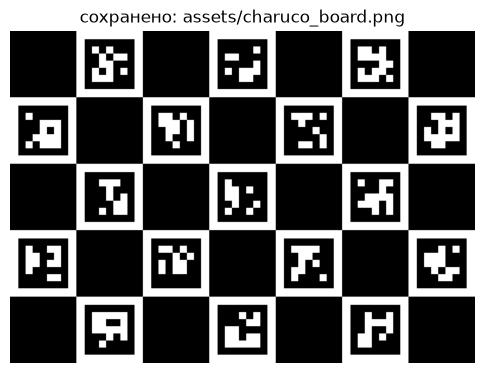

In [ ]:
ARUCO_DICT = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_5X5_100)
BOARD_SQUARES = (7, 5)                 # клеток по горизонтали и вертикали
SQUARE_SIZE_M = 0.035                  # сторона клетки, м
MARKER_SIZE_M = 0.75 * SQUARE_SIZE_M   # сторона маркера (соотношение 0.75 менять нельзя: так сгенерирована картинка)
BOARD = cv2.aruco.CharucoBoard(BOARD_SQUARES, SQUARE_SIZE_M, MARKER_SIZE_M, ARUCO_DICT)
CHARUCO_DETECTOR = cv2.aruco.CharucoDetector(BOARD)

# картинка доски: 300 dpi при клетке 35 мм
px_per_m = 300 / 0.0254
board_px = (round(BOARD_SQUARES[0] * SQUARE_SIZE_M * px_per_m), round(BOARD_SQUARES[1] * SQUARE_SIZE_M * px_per_m))
board_img = BOARD.generateImage(board_px, marginSize=0, borderBits=1)
cv2.imwrite("assets/charuco_board.png", cv2.copyMakeBorder(board_img, 60, 60, 60, 60, cv2.BORDER_CONSTANT, value=255))

plt.figure(figsize=(6, 4.5)); plt.imshow(board_img, cmap="gray"); plt.axis("off")
plt.title("сохранено: assets/charuco_board.png"); plt.show()

### 1.2 Получение калибровочных изображений

Выполните пункты 0.2 - 0.4 и отберите изображения для калибровки.

### 1.3 TODO: Калибровка

Дана функция`detect_charuco`, которая находит на кадре внутренние углы шахматной доски вместе с его 3D-координатами
на доске (`world_coords`, плоскость $Z = 0$, в метрах) и 2D-координаты на кадре (`img_pixels`, в пикселях). 

Выполните калировку камеры по кадрам, полученным в пункте 1.2 при помощи `cv2.calibrateCamera` (flags=cv2.CALIB_FIX_K3 для избежания переобучения).  

Выведите fx, fy, cx, cy, матрицу K, коэффициенты дисторсии (k1, k2, p1, p2, k3), горизонтальный и вертикальный углы обзора камеры (в градусах).

Сохраните K и dist.

Для одного кадра выведите оргинальное изображение и изображение после устранения дисторсии (`cv2.undistort`), посчитайте ошибку репроекции углов клеток.

In [ ]:
def detect_charuco(img, min_corners=8):
    """Находит углы доски ChArUco на кадре.

    img         — кадр RGB (H, W, 3) или серый (H, W).
    min_corners — минимальное число найденных углов; если меньше, кадр отбрасывается.

    Возвращает None (доска не найдена, углов мало или они лежат почти на одной прямой) или dict:
        obj — world_coords, (N, 3) float32: 3D-координаты углов в системе координат доски, в метрах:
              (столбец · SQUARE_SIZE_M, строка · SQUARE_SIZE_M, 0) — доска лежит в плоскости Z = 0;
        img — img_pixels, (N, 2) float32: координаты (u, v) тех же углов на кадре, в пикселях;
        ids — (N,) int: номера найденных углов — внутренних углов шахматной доски, от 0 до
              (BOARD_SQUARES[0] − 1) · (BOARD_SQUARES[1] − 1) − 1 (для доски 7×5 — от 0 до 23).
              Номер однозначно определяет угол, поэтому на разных кадрах может быть найден разный набор углов.
    Строка k во всех трёх массивах относится к одному и тому же углу.
    """
    # детектор работает с серым изображением
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) if img.ndim == 3 else img
    # углы доски в пикселях (N, 1, 2) и их номера (N, 1); найденные ArUco-маркеры (два последних значения) не нужны
    ch_corners, ch_ids, _, _ = CHARUCO_DETECTOR.detectBoard(gray)
    # доска не найдена или углов слишком мало
    if ch_ids is None or len(ch_ids) < min_corners:
        return None
    # по номеру угла — его 3D-координаты на доске; пиксельные координаты возвращаются в том же порядке
    world_coords, img_pixels = BOARD.matchImagePoints(ch_corners, ch_ids)
    # (N, 1, 3) → (N, 3)
    world_coords = world_coords.reshape(-1, 3).astype(np.float32)
    # (N, 1, 2) → (N, 2)
    img_pixels = img_pixels.reshape(-1, 2).astype(np.float32)
    # сингулярные числа центрированных точек — их разброс вдоль двух главных направлений
    sv = np.linalg.svd(img_pixels - img_pixels.mean(0), compute_uv=False)
    # углы почти на одной прямой — гомографию по ним не найти
    if sv[1] < 0.1 * sv[0]:
        return None
    # ids: (N, 1) → (N,)
    return dict(world_coords=world_coords, img_pixels=img_pixels, ids=ch_ids.ravel())

In [ ]:
calib_names, calib_frames = load_frames(CALIB_INPUT)  # load with the same WORK_MAX_SIDE image size
raise NotImplementedError()

# Часть 2. Ключевые кадры 

Выполните съемку выбранного объекта. Отберите ключевые кадры.

Если осуществлялась съемка видео, а несерии фото, можно автоматически отобрать кадры.

Из видео берём `VIDEO_FPS` кадров в секунду — это всё ещё слишком много и слишком похожие кадры. SfM нужны **ключевые кадры**:
1. **резкие** — смазанный кадр даёт мало особых точек и неточные координаты;
2. **с заметным сдвигом камеры** относительно предыдущего ключевого кадра — иначе нет параллакса, а значит и глубины;
3. **с достаточным перекрытием** с предыдущим ключевым кадром — иначе их не сопоставить.

* `sharpness(img)` — мера резкости: **дисперсия лапласиана** яркости (`cv2.Laplacian`). В смазанном кадре мало резких перепадов, и дисперсия мала.
* `select_keyframes(images)` — выбор ключевых кадров:
  * отбросить смазанные кадры. Порог — **относительный**: сравнивайте резкость с медианой по соседним кадрам, потому что абсолютная
    резкость зависит от сцены;
  * идти по оставшимся кадрам, сопоставлять каждый с последним ключевым и брать новый ключевой кадр, когда
    **перекрытие упало**: число сопоставлений стало меньше `min_overlap` от числа сопоставлений ключевого кадра со следующим
    за ним кадром. Дополнительно — когда **медианное смещение** точек превысило `max_motion` (доля диагонали кадра).
    Для сопоставления используйте готовые `quick_features` / `quick_match` (быстрый SIFT на уменьшенном кадре).



In [11]:
_QUICK_SIFT = cv2.SIFT_create(nfeatures=1500)
_QUICK_BF = cv2.BFMatcher(cv2.NORM_L2)


def quick_features(img, side=640):
    """Быстрый SIFT на уменьшенном кадре. Координаты точек — в пикселях исходного кадра."""
    s = side / max(img.shape[:2])
    small = cv2.resize(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY), None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
    kps, desc = _QUICK_SIFT.detectAndCompute(small, None)
    return np.float32([k.pt for k in kps]).reshape(-1, 2) / s, desc


def quick_match(fa, fb, ratio=0.75):
    """Сопоставление с ratio test Лоу. Возвращает пары точек (pa, pb), каждая формы (M, 2)."""
    (pa, da), (pb, db) = fa, fb
    if da is None or db is None or len(da) < 2 or len(db) < 2:
        return np.empty((0, 2), np.float32), np.empty((0, 2), np.float32)
    good = [m for m, n in (x for x in _QUICK_BF.knnMatch(da, db, k=2) if len(x) == 2) if m.distance < ratio * n.distance]
    return pa[[m.queryIdx for m in good]].reshape(-1, 2), pb[[m.trainIdx for m in good]].reshape(-1, 2)


def sharpness(img):
    """Дисперсия лапласиана яркости."""
    return cv2.Laplacian(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY), cv2.CV_64F).var()


def select_keyframes(images, min_overlap=0.7, max_motion=0.1, rel_sharpness=0.7, window=5):
    """Возвращает (индексы ключевых кадров, массив резкости всех кадров)."""
    n = len(images)
    sharp = np.array([sharpness(im) for im in images])
    local_median = np.array([np.median(sharp[max(0, k - window): k + window + 1]) for k in range(n)])
    candidates = np.flatnonzero(sharp >= rel_sharpness * local_median)
    diag = np.hypot(*images[0].shape[:2])
    keys = [int(candidates[0])]
    ref, full = quick_features(images[keys[0]]), None
    for k in candidates[1:]:
        cur = quick_features(images[k])
        pa, pb = quick_match(ref, cur)
        if full is None:                       # совпадений с первым кадром после ключевого — «полное перекрытие»
            full = max(len(pa), 1)
        motion = np.median(np.linalg.norm(pa - pb, axis=1)) / diag if len(pa) else np.inf
        if len(pa) < min_overlap * full or motion > max_motion:
            k = max((q for q in (k - 1, k, k + 1) if keys[-1] < q < n), key=lambda q: sharp[q])   # самый резкий из соседей
            keys.append(int(k))
            ref, full = quick_features(images[k]), None
    return keys, sharp

In [ ]:
scene_names, scene_frames = load_frames(SCENE_INPUT)

scene_size = scene_frames[0].shape[1::-1]

is_video = Path(SCENE_INPUT).suffix.lower() in VIDEO_EXT
if is_video:
    key_idx, sharp = select_keyframes(scene_frames)
else:
    key_idx, sharp = list(range(len(scene_frames))), np.array([sharpness(im) for im in scene_frames])

plt.figure(figsize=(15, 3))
plt.plot(sharp, ".-", lw=0.8, label="резкость кадра")
plt.plot(key_idx, sharp[key_idx], "o", mfc="none", ms=8, label="ключевые кадры")
plt.xlabel("кадр"); plt.legend(); plt.title(f"ключевых кадров: {len(key_idx)} из {len(scene_frames)}"); plt.show()

kf_images = [scene_frames[k] for k in key_idx]
kf_names = [scene_names[k] for k in key_idx]

show_grid(kf_images[:: max(1, len(kf_images) // 18)][:18], kf_names[:: max(1, len(kf_images) // 18)][:18])

# Часть 3. TODO: SfM

Реализуйте пайплайн Incremental SfM, запустите на своих данных, сохраните и визуализируйте sparse и dense point clouds.

# Часть 4. Optional: COLMAP

Необязательно. Запустите реконструкцию с помощью COLMAP: https://github.com/colmap/colmap (pip install pycolmap)


# Часть 5. Быть готовым ответить на следующие вопросы:

- Линейная модель камеры, матрицы внутренних и внешних параметров, уравнение в неоднородных координатах;
- Эпиполярная геометрия (эпиполи, эпиполярные линии, эпиполярная плоскость), существенная матрица E (что связывает – формула);
- Фундаментальная матрица F (что связывает – формула);
- Алгоритм RANSAC;
- Схема алгоритма Incremental SfM;
